# 🔧 Step 3: Feature Engineering — Telco Churn Prediction
### Acknobit Capstone Project
**Is notebook mein kya hoga:**
- Raw Telco dataset load karna
- Poori cleaning (TotalCharges fix, encoding, OHE)
- 5 naye features banana
- Train-Test Split + Scaling
- Saari files save karna (Drive pe)


## 📁 Step 0: Google Drive Mount Karo

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ✅ Apna folder path yahan set karo
BASE_PATH = '/content/drive/My Drive/Capstone Project/Churn Prediction'

import os
os.makedirs(f'{BASE_PATH}/data', exist_ok=True)
os.makedirs(f'{BASE_PATH}/models', exist_ok=True)
os.makedirs(f'{BASE_PATH}/plots', exist_ok=True)

print("✅ Drive mounted!")
print(f"Base path: {BASE_PATH}")


Mounted at /content/drive
✅ Drive mounted!
Base path: /content/drive/My Drive/Capstone Project/Churn Prediction


## 📦 Step 1: Libraries Import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("✅ Saari libraries load ho gayi!")


✅ Saari libraries load ho gayi!


## 📂 Step 2: Raw Data Load Karo

In [ ]:
# Raw CSV load karo — telco_cleaned nahi, ORIGINAL file!
RAW_DATA_PATH = f'{BASE_PATH}/data/Telco-Customer-Churn.csv'

df = pd.read_csv(RAW_DATA_PATH)

print(f"✅ Data loaded!")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head(3)


✅ Data loaded!
Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## 🧹 Step 3: Data Cleaning
Yahan hum saari cleaning ek saath karenge — sahi order mein!


In [ ]:
print("=" * 50)
print("DATA CLEANING SHURU")
print("=" * 50)

# ── 1. TotalCharges: string → float ───────────────────────────
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)
print(f"✅ TotalCharges fixed | Rows: {len(df)}")

# ── 2. customerID drop karo ────────────────────────────────────
df.drop('customerID', axis=1, inplace=True)
print("✅ customerID dropped")

# ── 3. Target variable encode karo ────────────────────────────
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(f"✅ Churn encoded | Churn rate: {df['Churn'].mean()*100:.2f}%")

# ── 4. gender encode karo ──────────────────────────────────────
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
print(f"✅ gender encoded | Nulls: {df['gender'].isnull().sum()}")

# ── 5. Simple binary columns (sirf Yes/No wale) ────────────────
simple_binary = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in simple_binary:
    df[col] = df[col].map({'Yes': 1, 'No': 0})
print(f"✅ {len(simple_binary)} binary columns encoded: {simple_binary}")

# ── 6. Internet service columns (Yes / No / No internet service)
# IMPORTANT: Ye 3 values hain — isliye alag treat karna pada!
internet_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in internet_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'No internet service': 0})
print(f"✅ {len(internet_cols)} internet service columns encoded")

# ── 7. One-Hot Encoding (3+ category wale columns) ─────────────
ohe_cols = ['MultipleLines', 'InternetService', 'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)

# Bool → int convert karo
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(f"✅ One-Hot Encoding done")

# ── Final check ────────────────────────────────────────────────
str_cols = df.select_dtypes(include='object').columns.tolist()
print(f"\n{'='*50}")
print(f"CLEANING COMPLETE!")
print(f"Shape: {df.shape}")
print(f"String columns bacha: {str_cols}  ← Empty hona chahiye!")
print(f"Null values: {df.isnull().sum().sum()}")
print(f"{'='*50}")


DATA CLEANING SHURU
✅ TotalCharges fixed | Rows: 7032
✅ customerID dropped
✅ Churn encoded | Churn rate: 26.58%
✅ gender encoded | Nulls: 0
✅ 4 binary columns encoded: ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
✅ 6 internet service columns encoded
✅ One-Hot Encoding done

CLEANING COMPLETE!
Shape: (7032, 25)
String columns bacha: []  ← Empty hona chahiye!
Null values: 0


## ⚙️ Step 4: Feature Engineering — 5 Naye Features
Raw features se zyada meaningful features banana.


In [ ]:
print("=" * 50)
print("FEATURE ENGINEERING SHURU")
print("=" * 50)

# ── Feature 1: Total Services Count ───────────────────────────
# Logic: Jitni zyada services → utna zyada invested → kam churn
df['total_services'] = df[internet_cols].sum(axis=1)
print(f"✅ Feature 1: total_services")
print(f"   Range: {df['total_services'].min()} to {df['total_services'].max()}")
print(f"   Churn rate by services:")
churn_by_svc = df.groupby('total_services')['Churn'].mean().round(3) * 100
print(f"   0 services: {churn_by_svc.get(0, 'N/A')}% | 6 services: {churn_by_svc.get(6, 'N/A')}%")

# ── Feature 2: Charge Per Tenure ──────────────────────────────
# Logic: Monthly charge / tenure — high value = naya expensive customer = churn risk
df['charge_per_tenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)
avg_churn = df.groupby('Churn')['charge_per_tenure'].mean().round(2)
print(f"\n✅ Feature 2: charge_per_tenure")
print(f"   Avg (No Churn): {avg_churn[0]} | Avg (Churn): {avg_churn[1]}")

# ── Feature 3: Is New Customer ────────────────────────────────
# Logic: 0-12 months = naya customer = high churn risk
df['is_new_customer'] = (df['tenure'] <= 12).astype(int)
churn_new = df.groupby('is_new_customer')['Churn'].mean().round(3) * 100
print(f"\n✅ Feature 3: is_new_customer")
print(f"   Old customer churn: {churn_new[0]}% | New customer churn: {churn_new[1]}%")

# ── Feature 4: Has No Protection ──────────────────────────────
# Logic: No security + No tech support = least attached to service
df['has_no_protection'] = (
    (df['OnlineSecurity'] == 0) & (df['TechSupport'] == 0)
).astype(int)
churn_prot = df.groupby('has_no_protection')['Churn'].mean().round(3) * 100
print(f"\n✅ Feature 4: has_no_protection")
print(f"   Has protection churn: {churn_prot[0]}% | No protection churn: {churn_prot[1]}%")

# ── Feature 5: Payment Consistency ────────────────────────────
# Logic: Actual total / Expected total — consistency measure
df['payment_consistency'] = df['TotalCharges'] / (
    df['tenure'] * df['MonthlyCharges'] + 1
)
print(f"\n✅ Feature 5: payment_consistency")
print(f"   Mean: {df['payment_consistency'].mean():.3f} (1.0 = perfectly consistent)")

print(f"\n{'='*50}")
print(f"Final shape: {df.shape}")
print(f"{'='*50}")


FEATURE ENGINEERING SHURU
✅ Feature 1: total_services
   Range: 0 to 6
   Churn rate by services:
   0 services: 21.5% | 6 services: 5.3%

✅ Feature 2: charge_per_tenure
   Avg (No Churn): 3.53 | Avg (Churn): 11.75

✅ Feature 3: is_new_customer
   Old customer churn: 17.1% | New customer churn: 47.699999999999996%

✅ Feature 4: has_no_protection
   Has protection churn: 17.1% | No protection churn: 33.5%

✅ Feature 5: payment_consistency
   Mean: 0.996 (1.0 = perfectly consistent)

Final shape: (7032, 30)


## 📊 Step 5: Correlation Check — Naye Features Useful Hain?

In [ ]:
new_features = [
    'total_services', 'charge_per_tenure',
    'is_new_customer', 'has_no_protection',
    'payment_consistency'
]

corr = df[new_features + ['Churn']].corr()['Churn'].drop('Churn')

print("Correlation of new features with Churn:")
print("-" * 40)
for feat, val in corr.sort_values(ascending=False).items():
    bar = "█" * int(abs(val) * 30)
    direction = "+" if val > 0 else "-"
    print(f"{feat:25s} {direction}{val:.3f}  {bar}")

print("\n💡 Insight:")
print("  charge_per_tenure & is_new_customer sabse strong predictors hain!")
print("  total_services negative hai — zyada services = kam churn (sahi hai!)")


Correlation of new features with Churn:
----------------------------------------
charge_per_tenure         +0.424  ████████████
is_new_customer           +0.320  █████████
has_no_protection         +0.183  █████
payment_consistency       --0.038  █
total_services            --0.088  ██

💡 Insight:
  charge_per_tenure & is_new_customer sabse strong predictors hain!
  total_services negative hai — zyada services = kam churn (sahi hai!)


## 📈 Step 6: Visualization — Naye Features Ka Plot

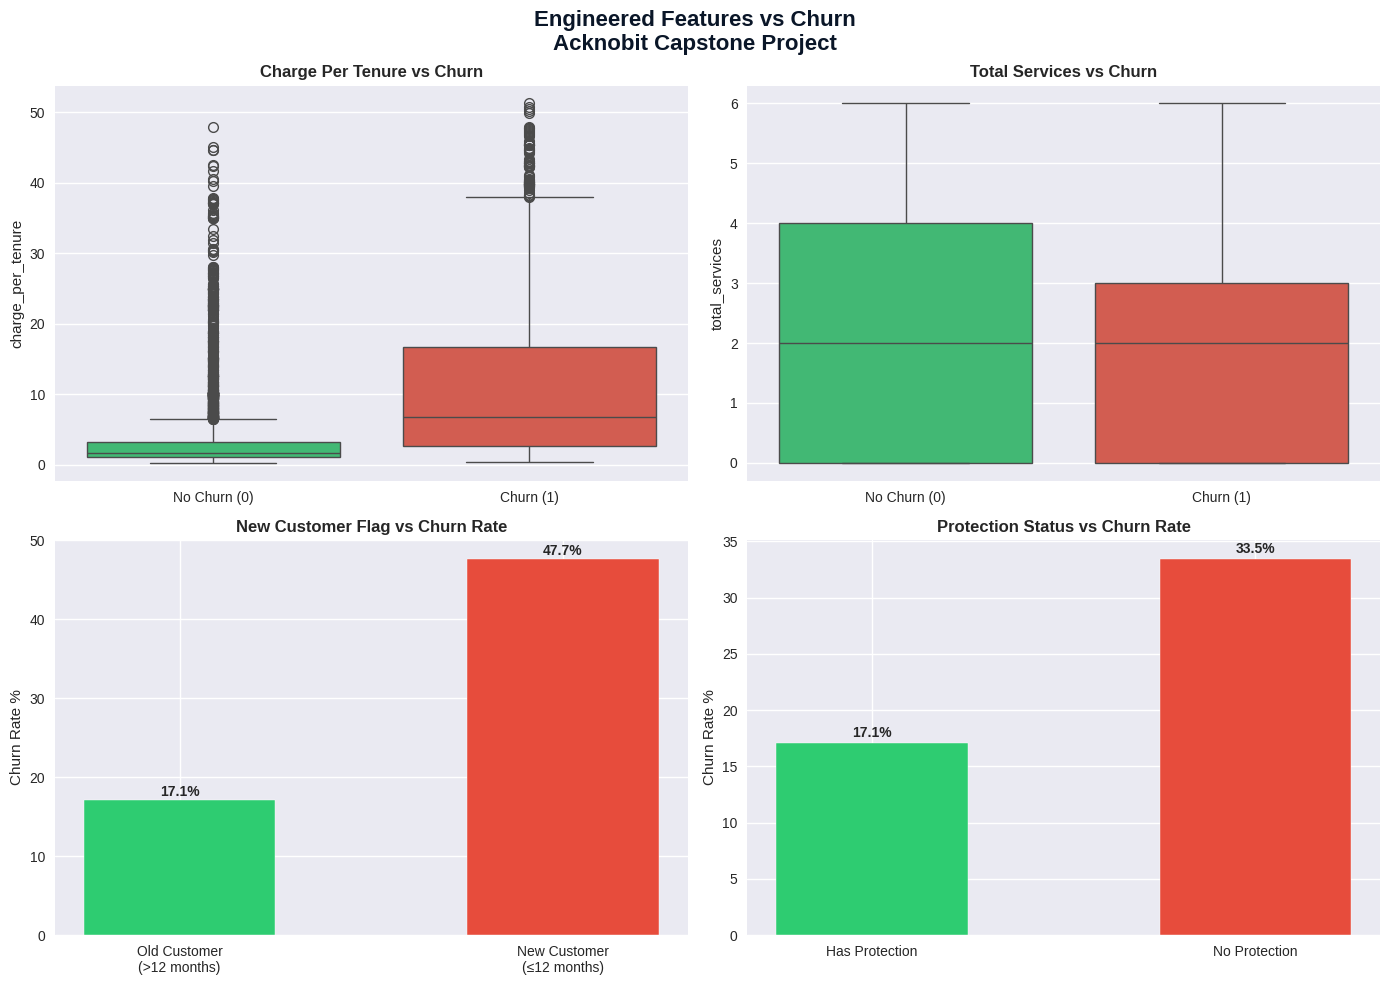

✅ Plot saved!


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Engineered Features vs Churn\nAcknobit Capstone Project',
             fontsize=16, fontweight='bold', color='#0A1628')

colors = ['#2ecc71', '#e74c3c']

# Plot 1: charge_per_tenure
sns.boxplot(data=df, x='Churn', y='charge_per_tenure',
            ax=axes[0,0], palette=colors)
axes[0,0].set_title('Charge Per Tenure vs Churn', fontweight='bold')
axes[0,0].set_xticklabels(['No Churn (0)', 'Churn (1)'])
axes[0,0].set_xlabel('')

# Plot 2: total_services
sns.boxplot(data=df, x='Churn', y='total_services',
            ax=axes[0,1], palette=colors)
axes[0,1].set_title('Total Services vs Churn', fontweight='bold')
axes[0,1].set_xticklabels(['No Churn (0)', 'Churn (1)'])
axes[0,1].set_xlabel('')

# Plot 3: is_new_customer
churn_new = df.groupby('is_new_customer')['Churn'].mean() * 100
axes[1,0].bar(['Old Customer\n(>12 months)', 'New Customer\n(≤12 months)'],
              churn_new.values, color=colors, width=0.5, edgecolor='white')
axes[1,0].set_title('New Customer Flag vs Churn Rate', fontweight='bold')
axes[1,0].set_ylabel('Churn Rate %')
for i, v in enumerate(churn_new.values):
    axes[1,0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Plot 4: has_no_protection
churn_prot = df.groupby('has_no_protection')['Churn'].mean() * 100
axes[1,1].bar(['Has Protection', 'No Protection'],
              churn_prot.values, color=colors, width=0.5, edgecolor='white')
axes[1,1].set_title('Protection Status vs Churn Rate', fontweight='bold')
axes[1,1].set_ylabel('Churn Rate %')
for i, v in enumerate(churn_prot.values):
    axes[1,1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/plots/05_engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")


## ✂️ Step 7: Train-Test Split

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"Total features: {X.shape[1]}")
print(f"Total samples: {X.shape[0]}")

# stratify=y → dono sets mein same churn ratio rahega
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"\n✅ Split complete!")
print(f"X_train: {X_train.shape} | Churn rate: {y_train.mean()*100:.2f}%")
print(f"X_test:  {X_test.shape} | Churn rate: {y_test.mean()*100:.2f}%")
print("\n💡 Dono mein same churn rate = stratify kaam kiya!")


Total features: 29
Total samples: 7032

✅ Split complete!
X_train: (5625, 29) | Churn rate: 26.58%
X_test:  (1407, 29) | Churn rate: 26.58%

💡 Dono mein same churn rate = stratify kaam kiya!


## ⚖️ Step 8: Feature Scaling
> ⚠️ **Rule:** Scaler sirf X_train pe fit karo, dono pe transform karo!
> Test data pe fit karna = **Data Leakage** hai!


In [ ]:
numerical_cols = [
    'tenure', 'MonthlyCharges', 'TotalCharges',
    'charge_per_tenure', 'payment_consistency'
]

scaler = StandardScaler()

# SIRF train pe fit!
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

# Test pe sirf transform (fit nahi!)
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("✅ Scaling complete!")
print(f"\nX_train numerical stats (Mean≈0, Std≈1 hona chahiye):")
print(X_train[numerical_cols].agg(['mean','std']).round(3))


✅ Scaling complete!

X_train numerical stats (Mean≈0, Std≈1 hona chahiye):
      tenure  MonthlyCharges  TotalCharges  charge_per_tenure  \
mean    -0.0             0.0           0.0               -0.0   
std      1.0             1.0           1.0                1.0   

      payment_consistency  
mean                  0.0  
std                   1.0  


## 💾 Step 9: Saari Files Save Karo

In [ ]:
# Cleaned + engineered full dataset
df.to_csv(f'{BASE_PATH}/data/telco_fully_cleaned.csv', index=False)

# Train / Test splits
X_train.to_csv(f'{BASE_PATH}/data/X_train.csv', index=False)
X_test.to_csv(f'{BASE_PATH}/data/X_test.csv', index=False)
y_train.to_csv(f'{BASE_PATH}/data/y_train.csv', index=False)
y_test.to_csv(f'{BASE_PATH}/data/y_test.csv', index=False)

# Scaler — Streamlit app mein use hoga!
joblib.dump(scaler, f'{BASE_PATH}/models/scaler.pkl')

print("✅ Saari files save ho gayi!")
print(f"\nDrive mein ye files hain ab:")
print(f"  data/telco_fully_cleaned.csv  → {df.shape}")
print(f"  data/X_train.csv              → {X_train.shape}")
print(f"  data/X_test.csv               → {X_test.shape}")
print(f"  data/y_train.csv              → {y_train.shape}")
print(f"  data/y_test.csv               → {y_test.shape}")
print(f"  models/scaler.pkl             → StandardScaler saved")


✅ Saari files save ho gayi!

Drive mein ye files hain ab:
  data/telco_fully_cleaned.csv  → (7032, 30)
  data/X_train.csv              → (5625, 29)
  data/X_test.csv               → (1407, 29)
  data/y_train.csv              → (5625,)
  data/y_test.csv               → (1407,)
  models/scaler.pkl             → StandardScaler saved


## ✅ Step 3 Complete — Summary

In [ ]:
print("=" * 55)
print("  STEP 3: FEATURE ENGINEERING — COMPLETE! ✅")
print("=" * 55)

print("=" * 55)
print("  STEP 3: FEATURE ENGINEERING COMPLETE!")
print("=" * 55)
print(f"Rows after cleaning : {len(df)}")
print(f"Total features      : {X_train.shape[1]}")
print(f"X_train shape       : {X_train.shape}")
print(f"X_test  shape       : {X_test.shape}")
print(f"Train churn rate    : {round(y_train.mean()*100, 2)}%")
print(f"Test  churn rate    : {round(y_test.mean()*100, 2)}%")
print("scaler.pkl saved    : YES")
print("=" * 55)
print("NEXT STEP --> 04_Model_Building.ipynb")
print("Models: Logistic Regression | Decision Tree | Random Forest | XGBoost")


  STEP 3: FEATURE ENGINEERING — COMPLETE! ✅
  STEP 3: FEATURE ENGINEERING COMPLETE!
Rows after cleaning : 7032
Total features      : 29
X_train shape       : (5625, 29)
X_test  shape       : (1407, 29)
Train churn rate    : 26.58%
Test  churn rate    : 26.58%
scaler.pkl saved    : YES
NEXT STEP --> 04_Model_Building.ipynb
Models: Logistic Regression | Decision Tree | Random Forest | XGBoost
